In [25]:
!pip install -q scikit-learn pandas matplotlib

In [26]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [27]:
dados = pd.DataFrame({
    "ID_Transacao": [f"T{i}" for i in range(1, 21)],
    "dataCompetencia": [
        "2026-04", "2026-04", "2026-04", "2026-04", "2026-04",
        "2026-04", "2026-04", "2026-04", "2026-04", "2026-04",
        "2026-05", "2026-05", "2026-05", "2026-05", "2026-05",
        "2026-05", "2026-05", "2026-05", "2026-05", "2026-05"
    ],
    "totalBilled": [
        150.5, 2500.0, 45.0, 3200.0, 120.0,
        180.0, 2100.0, 55.0, 3100.0, 130.0,
        160.5, 2600.0, 65.0, 3300.0, 140.0,
        140.0, 2400.0, 50.0, 3150.0, 110.0
    ],
    "diasAtrasoPagamento": [
        0, 15, 0, 30, 2,
        1, 14, 0, 28, 3,
        0, 16, 0, 32, 1,
        0, 12, 0, 29, 2
    ]
})

# 2. População da coluna quantidade com o valor de totalBilled
dados["quantidade"] = dados["totalBilled"]

dados

,ID_Transacao,dataCompetencia,totalBilled,diasAtrasoPagamento,quantidade
0,T1,2026-04,150.5,0,150.5
1,T2,2026-04,2500.0,15,2500.0
2,T3,2026-04,45.0,0,45.0
3,T4,2026-04,3200.0,30,3200.0
4,T5,2026-04,120.0,2,120.0
5,T6,2026-04,180.0,1,180.0
6,T7,2026-04,2100.0,14,2100.0
7,T8,2026-04,55.0,0,55.0
8,T9,2026-04,3100.0,28,3100.0
9,T10,2026-04,130.0,3,130.0


In [28]:
atributos = [
    "totalBilled",
    "diasAtrasoPagamento"
]

X = dados[atributos]

X.head()

,totalBilled,diasAtrasoPagamento
0,150.5,0
1,2500.0,15
2,45.0,0
3,3200.0,30
4,120.0,2


In [29]:
normalizador = StandardScaler()

X_normalizado = normalizador.fit_transform(X)

X_normalizado

array([[-0.77153634, -0.79941394],
       [ 0.98107376,  0.49693299],
       [-0.85023409, -0.79941394],
       [ 1.50323894,  1.79327992],
       [-0.79428782, -0.62656768],
       [-0.74953081, -0.71299081],
       [ 0.68269367,  0.41050986],
       [-0.84277459, -0.79941394],
       [ 1.42864391,  1.62043366],
       [-0.78682832, -0.54014455],
       [-0.76407684, -0.79941394],
       [ 1.05566879,  0.58335612],
       [-0.83531509, -0.79941394],
       [ 1.57783396,  1.96612617],
       [-0.77936882, -0.71299081],
       [-0.77936882, -0.79941394],
       [ 0.90647874,  0.2376636 ],
       [-0.84650434, -0.79941394],
       [ 1.46594143,  1.70685679],
       [-0.80174733, -0.62656768]])

In [30]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

dados["Cluster_KMeans"] = kmeans.fit_predict(X_normalizado)

dados[["ID_Transacao", "Cluster_KMeans"]]

,ID_Transacao,Cluster_KMeans
0,T1,0
1,T2,1
2,T3,0
3,T4,1
4,T5,0
5,T6,0
6,T7,1
7,T8,0
8,T9,1
9,T10,0


In [31]:
agnes = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

dados["Cluster_AGNES"] = agnes.fit_predict(X_normalizado)

dados[["ID_Transacao", "Cluster_AGNES"]]

,ID_Transacao,Cluster_AGNES
0,T1,1
1,T2,0
2,T3,1
3,T4,0
4,T5,1
5,T6,1
6,T7,0
7,T8,1
8,T9,0
9,T10,1


In [32]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=2
)

dados["Cluster_DBSCAN"] = dbscan.fit_predict(X_normalizado)

dados[["ID_Transacao", "Cluster_DBSCAN"]]

,ID_Transacao,Cluster_DBSCAN
0,T1,0
1,T2,1
2,T3,0
3,T4,2
4,T5,0
5,T6,0
6,T7,1
7,T8,0
8,T9,2
9,T10,0


In [33]:
dados[[
    "ID_Transacao",
    "dataCompetencia",
    "totalBilled",
    "quantidade",
    "diasAtrasoPagamento",
    "Cluster_KMeans",
    "Cluster_AGNES",
    "Cluster_DBSCAN"
]]

,ID_Transacao,dataCompetencia,totalBilled,quantidade,diasAtrasoPagamento,Cluster_KMeans,Cluster_AGNES,Cluster_DBSCAN
0,T1,2026-04,150.5,150.5,0,0,1,0
1,T2,2026-04,2500.0,2500.0,15,1,0,1
2,T3,2026-04,45.0,45.0,0,0,1,0
3,T4,2026-04,3200.0,3200.0,30,1,0,2
4,T5,2026-04,120.0,120.0,2,0,1,0
5,T6,2026-04,180.0,180.0,1,0,1,0
6,T7,2026-04,2100.0,2100.0,14,1,0,1
7,T8,2026-04,55.0,55.0,0,0,1,0
8,T9,2026-04,3100.0,3100.0,28,1,0,2
9,T10,2026-04,130.0,130.0,3,0,1,0


In [34]:
def calcular_silhouette(nome_algoritmo, labels):
    grupos = set(labels)

    if len(grupos) <= 1:
        return None

    grupos_reais = [g for g in grupos if g != -1]

    if len(grupos_reais) < 2:
        return None

    return silhouette_score(X_normalizado, labels)

resultados = pd.DataFrame({
    "Algoritmo": ["K-Means", "AGNES", "DBSCAN"],
    "Silhouette": [
        calcular_silhouette("K-Means", dados["Cluster_KMeans"]),
        calcular_silhouette("AGNES", dados["Cluster_AGNES"]),
        calcular_silhouette("DBSCAN", dados["Cluster_DBSCAN"])
    ]
})

resultados

,Algoritmo,Silhouette
0,K-Means,0.825611
1,AGNES,0.825611
2,DBSCAN,0.898053


In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_normalizado)

dados["PCA1"] = X_pca[:, 0]
dados["PCA2"] = X_pca[:, 1]

dados.head()

,ID_Transacao,dataCompetencia,totalBilled,diasAtrasoPagamento,quantidade,Cluster_KMeans,Cluster_AGNES,Cluster_DBSCAN,PCA1,PCA2
0,T1,2026-04,150.5,0,150.5,0,1,0,-1.110830,-0.019712
1,T2,2026-04,2500.0,15,2500.0,1,0,1,1.045109,-0.342339
2,T3,2026-04,45.0,0,45.0,0,1,0,-1.166477,0.035935
3,T4,2026-04,3200.0,30,3200.0,1,0,2,2.330991,0.205090
4,T5,2026-04,120.0,2,120.0,0,1,0,-1.004697,0.118596


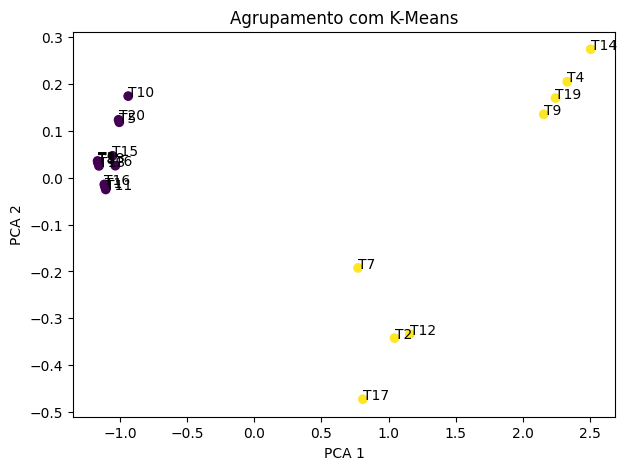

In [36]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dados["PCA1"],
    dados["PCA2"],
    c=dados["Cluster_KMeans"]
)

# No novo tema, "Pessoa" é substituído por "ID_Transacao"
for i, transacao in enumerate(dados["ID_Transacao"]):
    plt.text(dados["PCA1"][i], dados["PCA2"][i], transacao)

plt.title("Agrupamento com K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

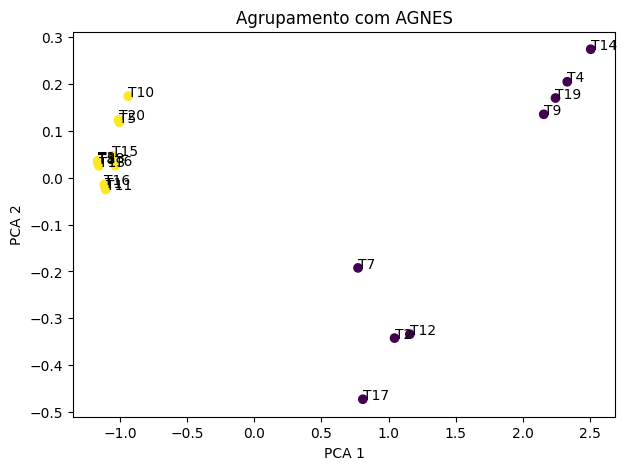

In [37]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dados["PCA1"],
    dados["PCA2"],
    c=dados["Cluster_AGNES"]
)

for i, transacao in enumerate(dados["ID_Transacao"]):
    plt.text(dados["PCA1"][i], dados["PCA2"][i], transacao)

plt.title("Agrupamento com AGNES")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

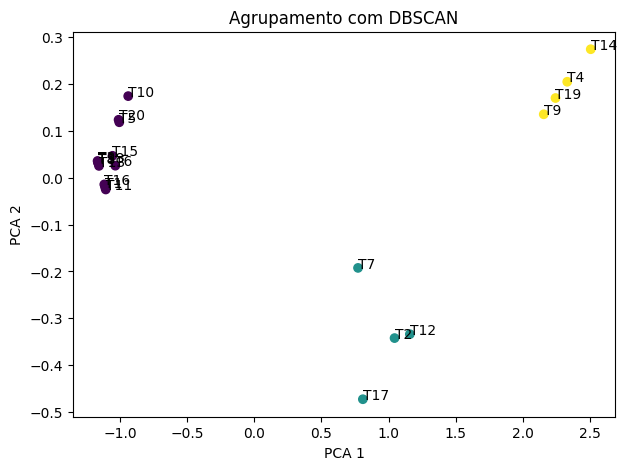

In [38]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dados["PCA1"],
    dados["PCA2"],
    c=dados["Cluster_DBSCAN"]
)

for i, transacao in enumerate(dados["ID_Transacao"]):
    plt.text(dados["PCA1"][i], dados["PCA2"][i], transacao)

plt.title("Agrupamento com DBSCAN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [39]:
perfil_kmeans = dados.groupby("Cluster_KMeans")[["totalBilled", "quantidade", "diasAtrasoPagamento"]].mean()

perfil_kmeans

,totalBilled,quantidade,diasAtrasoPagamento
Cluster_KMeans,,,
0,112.166667,112.166667,0.75
1,2793.750000,2793.750000,22.00


In [40]:
for cluster, linha in perfil_kmeans.iterrows():
    print(f"\nCluster {cluster} - K-Means")
    print(f"Faturamento médio (totalBilled): R$ {linha['totalBilled']:.2f}")
    print(f"Quantidade média: {linha['quantidade']:.1f}")
    print(f"Atraso médio: {linha['diasAtrasoPagamento']:.1f} dias")



Cluster 0 - K-Means
Faturamento médio (totalBilled): R$ 112.17
Quantidade média: 112.2
Atraso médio: 0.8 dias

Cluster 1 - K-Means
Faturamento médio (totalBilled): R$ 2793.75
Quantidade média: 2793.8
Atraso médio: 22.0 dias


In [41]:
perfil_agnes = dados.groupby("Cluster_AGNES")[["totalBilled", "quantidade", "diasAtrasoPagamento"]].mean()

perfil_agnes

,totalBilled,quantidade,diasAtrasoPagamento
Cluster_AGNES,,,
0,2793.750000,2793.750000,22.00
1,112.166667,112.166667,0.75


In [42]:
for cluster, linha in perfil_agnes.iterrows():
    print(f"\nCluster {cluster} - AGNES")
    print(f"Faturamento médio (totalBilled): R$ {linha['totalBilled']:.2f}")
    print(f"Quantidade média: {linha['quantidade']:.1f}")
    print(f"Atraso médio: {linha['diasAtrasoPagamento']:.1f} dias")


Cluster 0 - AGNES
Faturamento médio (totalBilled): R$ 2793.75
Quantidade média: 2793.8
Atraso médio: 22.0 dias

Cluster 1 - AGNES
Faturamento médio (totalBilled): R$ 112.17
Quantidade média: 112.2
Atraso médio: 0.8 dias


In [43]:
perfil_dbscan = dados.groupby("Cluster_DBSCAN")[["totalBilled", "quantidade", "diasAtrasoPagamento"]].mean()

perfil_dbscan

,totalBilled,quantidade,diasAtrasoPagamento
Cluster_DBSCAN,,,
0,112.166667,112.166667,0.75
1,2400.000000,2400.000000,14.25
2,3187.500000,3187.500000,29.75


In [44]:
for cluster, linha in perfil_dbscan.iterrows():
    if cluster == -1:
        nome_cluster = "Ruído / transação atípica"
    else:
        nome_cluster = f"Cluster {cluster}"

    print(f"\n{nome_cluster} - DBSCAN")
    print(f"Faturamento médio (totalBilled): R$ {linha['totalBilled']:.2f}")
    print(f"Quantidade média: {linha['quantidade']:.1f}")
    print(f"Atraso médio: {linha['diasAtrasoPagamento']:.1f} dias")


Cluster 0 - DBSCAN
Faturamento médio (totalBilled): R$ 112.17
Quantidade média: 112.2
Atraso médio: 0.8 dias

Cluster 1 - DBSCAN
Faturamento médio (totalBilled): R$ 2400.00
Quantidade média: 2400.0
Atraso médio: 14.2 dias

Cluster 2 - DBSCAN
Faturamento médio (totalBilled): R$ 3187.50
Quantidade média: 3187.5
Atraso médio: 29.8 dias


In [45]:
def interpretar_clusters(df, nome_coluna_cluster):
    perfis = df.groupby(nome_coluna_cluster)[atributos].mean()
    for cluster, linha in perfis.iterrows():
        print("="*60)
        if cluster == -1:
            print("Grupo -1: possíveis casos atípicos detectados pelo DBSCAN")
        else:
            print(f"Grupo {cluster}")

        interpretacao = []
        if linha["totalBilled"] > 1000:
            interpretacao.append("Transações de alto valor (High Ticket)")
        elif linha["totalBilled"] < 200:
            interpretacao.append("Ticket médio baixo")
        else:
            interpretacao.append("Faturamentos intermediários")

        if linha["diasAtrasoPagamento"] >= 15:
            interpretacao.append("com atraso significativo no pagamento")
        elif linha["diasAtrasoPagamento"] == 0:
            interpretacao.append("pagamentos rigorosamente em dia")
        else:
            interpretacao.append("pequenos atrasos toleráveis")

        print("Perfil:", ", ".join(interpretacao))

In [46]:
interpretar_clusters(dados, "Cluster_KMeans")

Grupo 0
Perfil: Ticket médio baixo, pequenos atrasos toleráveis
Grupo 1
Perfil: Transações de alto valor (High Ticket), com atraso significativo no pagamento


In [47]:
interpretar_clusters(dados, "Cluster_AGNES")

Grupo 0
Perfil: Transações de alto valor (High Ticket), com atraso significativo no pagamento
Grupo 1
Perfil: Ticket médio baixo, pequenos atrasos toleráveis


In [48]:
interpretar_clusters(dados, "Cluster_DBSCAN")

Grupo 0
Perfil: Ticket médio baixo, pequenos atrasos toleráveis
Grupo 1
Perfil: Transações de alto valor (High Ticket), pequenos atrasos toleráveis
Grupo 2
Perfil: Transações de alto valor (High Ticket), com atraso significativo no pagamento
